In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
universities=pd.read_csv('Universities.csv',index_col='Univ')

In [9]:
universities

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,1310,89,22,13,22704,94
CalTech,1415,100,25,6,63575,81
CMU,1260,62,59,9,25026,72
Columbia,1310,76,24,12,31510,88
Cornell,1280,83,33,13,21864,90
Dartmouth,1340,89,23,10,32162,95
Duke,1315,90,30,12,31585,95
Georgetown,1255,74,24,12,20126,92
Harvard,1400,91,14,11,39525,97


In [10]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
scale_df=scale.fit_transform(universities)

In [34]:
from sklearn.decomposition import PCA
pmodel=PCA(n_components=6)
pcomps=pmodel.fit_transform(scale_df)


In [35]:
pca_df= pd.DataFrame(pcomps,columns=['PC1','PC2','PC3','PC4','PC5','PC6'],index=universities.index)

In [36]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6
Univ,,,,,,
Brown,-1.009874,-1.064310,0.081066,0.056951,-0.128754,-0.034650
CalTech,-2.822238,2.259045,0.836829,0.143845,-0.125962,-0.180703
CMU,1.112466,1.631209,-0.266787,1.075075,-0.191814,0.345679
Columbia,-0.741741,-0.042187,0.060501,-0.157208,-0.577611,0.109163
Cornell,-0.311912,-0.635244,0.010241,0.171364,0.012726,-0.016921
Dartmouth,-1.696691,-0.344363,-0.253408,0.012564,-0.052661,-0.027166
Duke,-1.246821,-0.490984,-0.032094,-0.205644,0.293505,-0.078012
Georgetown,-0.338750,-0.785169,-0.493585,0.039856,-0.544979,-0.155372
Harvard,-2.374150,-0.386539,0.116098,-0.453366,-0.230108,0.266984


In [37]:
np.round(pmodel.explained_variance_ratio_,3)

array([0.769, 0.131, 0.048, 0.027, 0.021, 0.004])

In [38]:
np.cumsum(pmodel.explained_variance_ratio_)

array([0.76868084, 0.89981687, 0.94757718, 0.97487386, 0.99559156,
       1.        ])

In [43]:
varian=np.round(pmodel.explained_variance_ratio_,3)

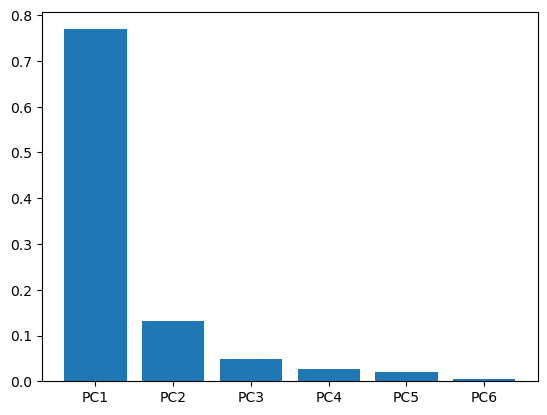

In [45]:
plt.bar(pca_df.columns,varian)
plt.show()

In [39]:
final_data=pca_df[['PC1','PC2','PC3']]

In [40]:
final_data

,PC1,PC2,PC3
Univ,,,
Brown,-1.009874,-1.064310,0.081066
CalTech,-2.822238,2.259045,0.836829
CMU,1.112466,1.631209,-0.266787
Columbia,-0.741741,-0.042187,0.060501
Cornell,-0.311912,-0.635244,0.010241
Dartmouth,-1.696691,-0.344363,-0.253408
Duke,-1.246821,-0.490984,-0.032094
Georgetown,-0.338750,-0.785169,-0.493585
Harvard,-2.374150,-0.386539,0.116098


### TSNE for visualization

In [41]:
from sklearn.manifold import TSNE

In [42]:
iris=pd.read_csv('iris.csv')

In [21]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [23]:
data=iris.copy()

In [24]:
features=data.drop("species",axis=1)

In [27]:
t_model=TSNE(n_components=2)
tcomps=t_model.fit_transform(features)

In [28]:
tcomps

array([[-23.875437  ,  -1.4305894 ],
       [-21.332832  ,  -2.5229647 ],
       [-21.183956  ,  -1.3164853 ],
       [-20.842545  ,  -1.61192   ],
       [-23.845785  ,  -0.9457335 ],
       [-25.833662  ,  -0.9249592 ],
       [-21.434713  ,  -0.7261155 ],
       [-23.135448  ,  -1.5997264 ],
       [-20.077644  ,  -1.7236085 ],
       [-21.728899  ,  -2.2258704 ],
       [-25.438894  ,  -1.6185867 ],
       [-22.392347  ,  -1.1686792 ],
       [-20.983025  ,  -2.2591443 ],
       [-19.860811  ,  -1.1332073 ],
       [-26.776562  ,  -1.5117849 ],
       [-26.88732   ,  -0.9376887 ],
       [-26.012383  ,  -1.2746142 ],
       [-23.93844   ,  -1.5569798 ],
       [-26.26575   ,  -1.8069136 ],
       [-24.88065   ,  -0.82918686],
       [-24.896988  ,  -2.4844184 ],
       [-24.62376   ,  -1.0674903 ],
       [-21.465752  ,   0.10849005],
       [-23.518333  ,  -2.8430624 ],
       [-22.436312  ,  -0.6163109 ],
       [-21.753988  ,  -2.7942991 ],
       [-23.376272  ,  -2.279838  ],
 

In [29]:
tsne_df=pd.DataFrame(tcomps,columns=['T1','T2'])
tsne_df

,T1,T2
0,-23.875437,-1.430589
1,-21.332832,-2.522965
2,-21.183956,-1.316485
3,-20.842545,-1.611920
4,-23.845785,-0.945733
...,...,...
145,15.408048,-1.407380
146,12.035444,-1.459038
147,14.410233,-1.398059
148,15.347630,-3.389599


In [30]:
tsne_df['species']=iris['species']

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


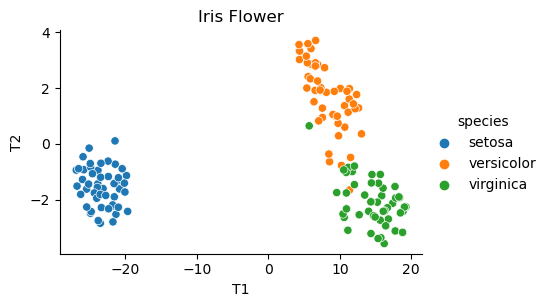

In [33]:
sns.relplot(tsne_df,x='T1',y='T2',kind='scatter',hue='species',height=3,aspect=1.5)
plt.title('Iris Flower')
plt.show()